# FLO Customer Segmentation with Unsupervised Learning

The objective of this project is to segment FLO customers based on their purchasing behavior using unsupervised learning techniques.

The project includes feature engineering, data standardization, K-Means clustering, hierarchical clustering, and segment profiling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## 1. Data Understanding

The dataset is examined to understand its structure, variable types, descriptive statistics, missing values, and unique values before preprocessing and customer segmentation.

In [4]:
def check_df(dataframe, head=5):
    """
    Provides a general overview of the dataset.
    """

    print("##################### Shape #####################")
    print(dataframe.shape)

    print("##################### Types #####################")
    print(dataframe.dtypes)

    print("##################### Head #####################")
    print(dataframe.head(head))

    print("##################### Tail #####################")
    print(dataframe.tail(head))

    print("##################### NA #####################")
    print(dataframe.isnull().sum())

    print("##################### Quantiles #####################")
    print(
        dataframe.describe(
            percentiles=[0, 0.05, 0.50, 0.95, 0.99, 1]
        ).T
    )

In [5]:
check_df(df)

##################### Shape #####################
(19945, 12)
##################### Types #####################
master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_total_ever_online     float64
interested_in_categories_12           object
dtype: object
##################### Head #####################
                              master_id order_channel last_order_channel first_order_date last_order_date last_order_date_online last_order_date_offline  order_num_total_ever_online  order_num_total_ever_offline  customer_value_total_ever_offline  customer_value_total_ever_online     

In [6]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns categorical, numerical and cardinal categorical variables.
    """

    # Categorical variables
    cat_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtypes == "O"
    ]

    # Numerical but categorical variables
    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th
        and dataframe[col].dtypes != "O"
    ]

    # Categorical but cardinal variables
    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th
        and dataframe[col].dtypes == "O"
    ]

    cat_cols = [
        col for col in cat_cols
        if col not in cat_but_car
    ]

    cat_cols = cat_cols + num_but_cat

    # Numerical variables
    num_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtypes != "O"
    ]

    num_cols = [
        col for col in num_cols
        if col not in num_but_cat
    ]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [7]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print("\nCategorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

print("\nCardinal Categorical Columns:")
print(cat_but_car)

Observations: 19945
Variables: 12
cat_cols: 2
num_cols: 4
cat_but_car: 6
num_but_cat: 0

Categorical Columns:
['order_channel', 'last_order_channel']

Numerical Columns:
['order_num_total_ever_online', 'order_num_total_ever_offline', 'customer_value_total_ever_offline', 'customer_value_total_ever_online']

Cardinal Categorical Columns:
['master_id', 'first_order_date', 'last_order_date', 'last_order_date_online', 'last_order_date_offline', 'interested_in_categories_12']


## 2. Data Preparation

Date variables are converted to datetime format before creating customer-level behavioral features.

In [8]:
# Define date columns

date_cols = [
    "first_order_date",
    "last_order_date",
    "last_order_date_online",
    "last_order_date_offline"
]

# Convert date columns to datetime format

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Check data types
df[date_cols].dtypes

first_order_date           datetime64[ns]
last_order_date            datetime64[ns]
last_order_date_online     datetime64[ns]
last_order_date_offline    datetime64[ns]
dtype: object

## 3. Feature Engineering

In [9]:
# Define analysis date

analysis_date = df["last_order_date"].max() + pd.Timedelta(days=2)

print("Analysis Date:", analysis_date)

Analysis Date: 2021-06-01 00:00:00


In [10]:
# Customer tenure in days

df["TENURE"] = (
    analysis_date - df["first_order_date"]
).dt.days

In [11]:
# Days since the customer's last purchase

df["RECENCY"] = (
    analysis_date - df["last_order_date"]
).dt.days

In [12]:
# Total number of orders across online and offline channels

df["TOTAL_ORDER_NUM"] = (
    df["order_num_total_ever_online"] +
    df["order_num_total_ever_offline"]
)

In [13]:
# Total monetary value across online and offline channels

df["TOTAL_CUSTOMER_VALUE"] = (
    df["customer_value_total_ever_online"] +
    df["customer_value_total_ever_offline"]
)

In [14]:
new_features = [
    "TENURE",
    "RECENCY",
    "TOTAL_ORDER_NUM",
    "TOTAL_CUSTOMER_VALUE"
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TENURE,19945.000,801.303,523.397,5.000,517.000,651.000,836.000,3060.000
RECENCY,19945.000,134.458,103.281,2.000,43.000,111.000,202.000,367.000
TOTAL_ORDER_NUM,19945.000,5.025,4.743,2.000,3.000,4.000,6.000,202.000
TOTAL_CUSTOMER_VALUE,19945.000,751.244,895.402,44.980,339.980,545.270,897.780,45905.100


In [15]:
df[new_features].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
TENURE,19945.000,801.303,523.397,5.000,209.200,517.000,651.000,836.000,2074.000,2605.000,3060.000
RECENCY,19945.000,134.458,103.281,2.000,9.000,43.000,111.000,202.000,335.000,360.000,367.000
TOTAL_ORDER_NUM,19945.000,5.025,4.743,2.000,2.000,3.000,4.000,6.000,12.000,22.000,202.000
TOTAL_CUSTOMER_VALUE,19945.000,751.244,895.402,44.980,175.480,339.980,545.270,897.780,1921.924,3606.356,45905.100


## 4. Outlier Treatment

Extreme values in customer behavioral variables are capped before clustering because distance-based algorithms such as K-Means are sensitive to outliers.

In [16]:
def outlier_thresholds(dataframe, variable, q1=0.01, q3=0.99):
    quartile1 = dataframe[variable].quantile(q1)
    quartile3 = dataframe[variable].quantile(q3)

    interquantile_range = quartile3 - quartile1

    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range

    return low_limit, up_limit


def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)

    dataframe.loc[
        dataframe[variable] < low_limit,
        variable
    ] = low_limit

    dataframe.loc[
        dataframe[variable] > up_limit,
        variable
    ] = up_limit

In [17]:
outlier_cols = [
    "TOTAL_ORDER_NUM",
    "TOTAL_CUSTOMER_VALUE"
]

for col in outlier_cols:
    replace_with_thresholds(df, col)

In [18]:
df[new_features].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
TENURE,19945.000,801.303,523.397,5.000,209.200,517.000,651.000,836.000,2074.000,2605.000,3060.000
RECENCY,19945.000,134.458,103.281,2.000,9.000,43.000,111.000,202.000,335.000,360.000,367.000
TOTAL_ORDER_NUM,19945.000,4.999,4.260,2.000,2.000,3.000,4.000,6.000,12.000,22.000,52.000
TOTAL_CUSTOMER_VALUE,19945.000,743.392,701.942,44.980,175.480,339.980,545.270,897.780,1921.924,3606.356,8844.919


## 5. Feature Selection for Clustering

Select behavioral variables that represent customer tenure, recency, purchasing frequency, and monetary value.

In [19]:
cluster_cols = [
    "TENURE",
    "RECENCY",
    "TOTAL_ORDER_NUM",
    "TOTAL_CUSTOMER_VALUE"
]

X = df[cluster_cols].copy()

X.head()

,TENURE,RECENCY,TOTAL_ORDER_NUM,TOTAL_CUSTOMER_VALUE
0,214,95,5.000,939.370
1,1574,105,21.000,2013.550
2,552,186,5.000,585.320
3,146,135,2.000,121.970
4,668,86,2.000,209.980


## 6. Standardization

Standardize clustering variables before applying distance-based clustering algorithms.

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_cols,
    index=X.index
)

X_scaled.head()

,TENURE,RECENCY,TOTAL_ORDER_NUM,TOTAL_CUSTOMER_VALUE
0,-1.122,-0.382,0.000,0.279
1,1.476,-0.285,3.756,1.810
2,-0.476,0.499,0.000,-0.225
3,-1.252,0.005,-0.704,-0.885
4,-0.255,-0.469,-0.704,-0.760


In [21]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
TENURE,19945.000,0.000,1.000,-1.521,-0.543,-0.287,0.066,4.316
RECENCY,19945.000,0.000,1.000,-1.283,-0.886,-0.227,0.654,2.252
TOTAL_ORDER_NUM,19945.000,0.000,1.000,-0.704,-0.469,-0.234,0.235,11.033
TOTAL_CUSTOMER_VALUE,19945.000,0.000,1.000,-0.995,-0.575,-0.282,0.220,11.542


## 7. K-Means Customer Segmentation

K-Means clustering is applied to group customers with similar purchasing behaviors.

Since K-Means requires the number of clusters to be specified in advance, the optimal number of clusters is first investigated using the Elbow Method.

In [22]:
# Store SSD (inertia) values for different numbers of clusters

ssd = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    ssd.append(kmeans.inertia_)

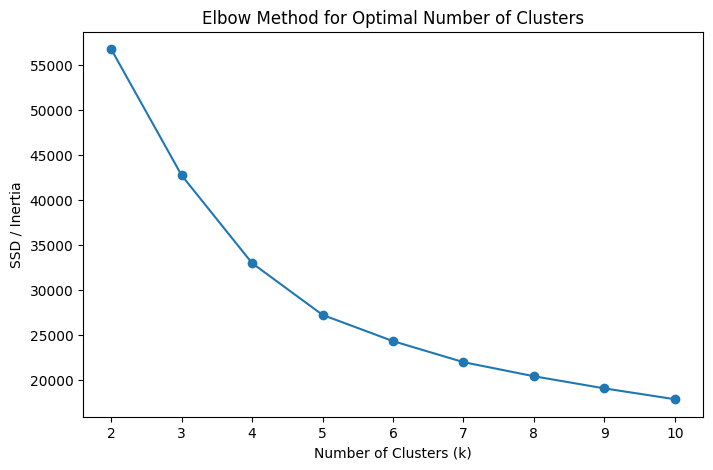

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    ssd,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSD / Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

### Interpretation

The Elbow Method evaluates how the within-cluster sum of squared distances changes as the number of clusters increases.

The point where the decrease in inertia begins to slow down can be considered a suitable number of clusters.

### Elbow Method Interpretation

The inertia decreases substantially as the number of clusters increases from 2 to 5.

After approximately **k = 5**, the rate of improvement begins to slow down. Therefore, **5 clusters** were selected for the K-Means model.

In [24]:
# Build the final K-Means model with 5 clusters

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit the model and assign each customer to a cluster
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["KMEANS_CLUSTER"] = clusters

df[["master_id", "KMEANS_CLUSTER"]].head()

,master_id,KMEANS_CLUSTER
0,cc294636-19f0-11eb-8d74-000d3a38a36f,4
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,1
2,69b69676-1a40-11ea-941b-000d3a38a36f,0
3,1854e56c-491f-11eb-806e-000d3a38a36f,4
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,4


In [25]:
# Number of customers in each cluster

df["KMEANS_CLUSTER"].value_counts().sort_index()

KMEANS_CLUSTER
0    5820
1     460
2    2723
3    1881
4    9061
Name: count, dtype: int64

In [26]:
# Percentage distribution of customers across clusters

(
    df["KMEANS_CLUSTER"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

KMEANS_CLUSTER
0   29.180
1    2.310
2   13.650
3    9.430
4   45.430
Name: proportion, dtype: float64

In [27]:
# Analyze the behavioral characteristics of each cluster

cluster_summary = df.groupby("KMEANS_CLUSTER")[
    cluster_cols
].agg(["mean", "median"])

cluster_summary.round(2)

TENURE          RECENCY         TOTAL_ORDER_NUM        TOTAL_CUSTOMER_VALUE         
                   mean   median    mean  median            mean median                 mean   median
KMEANS_CLUSTER                                                                                       
0               684.920  640.000 255.560 245.000           3.520  3.000              505.460  443.950
1              1538.770 1531.000  92.980  61.000          23.710 21.000             3728.580 3312.280
2               843.120  792.000  82.950  64.000           9.180  9.000             1510.560 1408.680
3              2031.640 2030.000 159.720 145.000           6.080  5.000              759.070  679.910
4               570.640  579.000  69.020  63.000           3.520  3.000              510.860  465.660

### Cluster Interpretation

The five K-Means clusters represent distinct customer behavioral profiles:

- **Cluster 0 – At Risk Customers:** Customers with relatively low purchase frequency and monetary value who have not purchased recently.
- **Cluster 1 – High Value Loyal Customers:** Long-term customers with the highest purchase frequency and monetary value.
- **Cluster 2 – Loyal Active Customers:** Active customers with relatively high purchase frequency and spending.
- **Cluster 3 – Long-Term Slipping Customers:** Long-term customers whose recent purchasing activity has decreased.
- **Cluster 4 – Recent Low-Frequency Customers:** Recently active customers with relatively low purchase frequency and monetary value.

These segments can be used to develop different customer relationship and marketing strategies.

In [28]:
# Number of customers in each cluster

cluster_counts = (
    df.groupby("KMEANS_CLUSTER")
    .size()
    .rename("CUSTOMER_COUNT")
)

cluster_counts

KMEANS_CLUSTER
0    5820
1     460
2    2723
3    1881
4    9061
Name: CUSTOMER_COUNT, dtype: int64

In [29]:
# Assign meaningful business names to K-Means clusters

segment_map = {
    0: "At Risk",
    1: "High Value Loyal",
    2: "Loyal Active",
    3: "Long-Term Slipping",
    4: "Recent Low-Frequency"
}

df["KMEANS_SEGMENT"] = df["KMEANS_CLUSTER"].map(segment_map)

df[
    [
        "master_id",
        "KMEANS_CLUSTER",
        "KMEANS_SEGMENT"
    ]
].head()

,master_id,KMEANS_CLUSTER,KMEANS_SEGMENT
0,cc294636-19f0-11eb-8d74-000d3a38a36f,4,Recent Low-Frequency
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,1,High Value Loyal
2,69b69676-1a40-11ea-941b-000d3a38a36f,0,At Risk
3,1854e56c-491f-11eb-806e-000d3a38a36f,4,Recent Low-Frequency
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,4,Recent Low-Frequency


In [30]:
# Number of customers in each business segment

df["KMEANS_SEGMENT"].value_counts()

KMEANS_SEGMENT
Recent Low-Frequency    9061
At Risk                 5820
Loyal Active            2723
Long-Term Slipping      1881
High Value Loyal         460
Name: count, dtype: int64

### Marketing Strategy Recommendations

- **High Value Loyal:** Loyalty programs, VIP benefits, early access to new products, and personalized premium campaigns can be used to retain these highly valuable customers.

- **Loyal Active:** Cross-selling and personalized product recommendations can be used to increase customer value and move these customers toward the high-value segment.

- **Recent Low-Frequency:** Second-purchase incentives, personalized discounts, and category-based recommendations can be used to increase purchase frequency.

- **Long-Term Slipping:** Reactivation campaigns and personalized offers can be designed to regain the attention of these long-term customers.

- **At Risk:** Win-back campaigns, special discounts, and reminder communications can be used to reactivate customers who have not purchased for a long period.

## 8. Hierarchical Clustering

Hierarchical clustering is applied as an alternative unsupervised learning method to segment customers based on their purchasing behavior.

A dendrogram is first examined to determine an appropriate number of clusters.

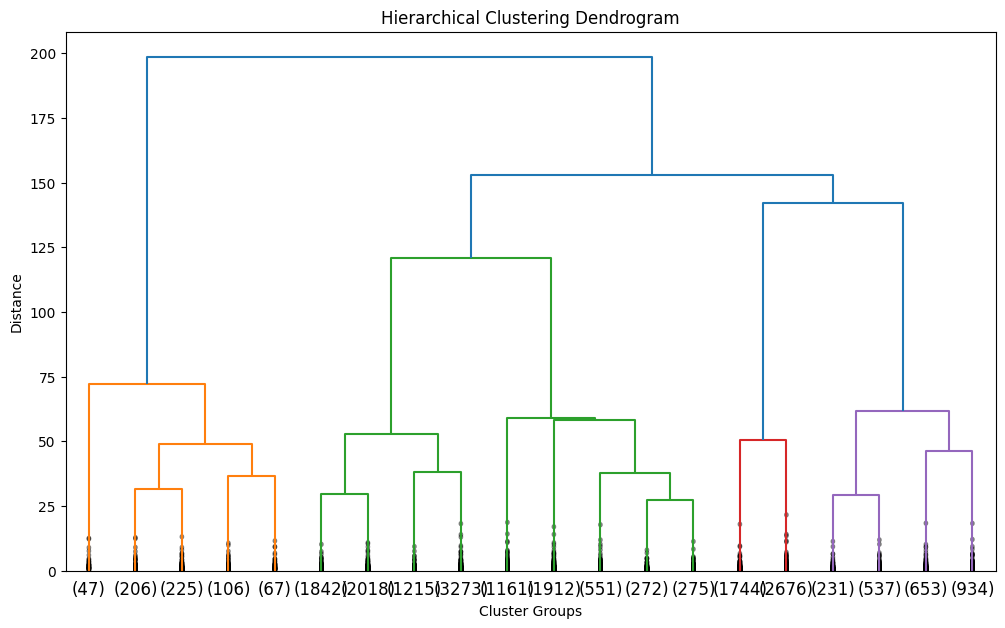

In [31]:
# Create hierarchical linkage matrix
# "ward" method aims to minimize variance within clusters

hc_complete = linkage(
    X_scaled,
    method="ward"
)

# Plot dendrogram

plt.figure(figsize=(12, 7))

dendrogram(
    hc_complete,
    truncate_mode="lastp",
    p=20,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")

plt.show()

### Dendrogram Interpretation

The dendrogram shows several distinct customer groups separated by relatively large linkage distances.

Based on the hierarchical structure and to maintain comparability with the K-Means solution, **5 clusters** were selected for the hierarchical clustering model.

In [32]:
# Build the Agglomerative Hierarchical Clustering model

hc_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

# Assign each customer to a hierarchical cluster

hc_clusters = hc_model.fit_predict(X_scaled)

# Add cluster labels to the original dataframe

df["HC_CLUSTER"] = hc_clusters

df[
    ["master_id", "HC_CLUSTER"]
].head()

,master_id,HC_CLUSTER
0,cc294636-19f0-11eb-8d74-000d3a38a36f,4
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,0
2,69b69676-1a40-11ea-941b-000d3a38a36f,4
3,1854e56c-491f-11eb-806e-000d3a38a36f,3
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,4


In [33]:
# Number of customers in each hierarchical cluster

df["HC_CLUSTER"].value_counts().sort_index()

HC_CLUSTER
0     651
1    4171
2    2355
3    4420
4    8348
Name: count, dtype: int64

In [34]:
# Percentage distribution of hierarchical clusters

(
    df["HC_CLUSTER"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

HC_CLUSTER
0    3.260
1   20.910
2   11.810
3   22.160
4   41.860
Name: proportion, dtype: float64

In [35]:
# Analyze behavioral characteristics of hierarchical clusters

hc_summary = df.groupby("HC_CLUSTER")[
    cluster_cols
].agg(["mean", "median"])

hc_summary.round(2)

TENURE          RECENCY         TOTAL_ORDER_NUM        TOTAL_CUSTOMER_VALUE         
               mean   median    mean  median            mean median                 mean   median
HC_CLUSTER                                                                                       
0          1610.150 1608.000  90.470  65.000          21.010 19.000             3229.780 2888.090
1           768.160  702.000 105.490  78.000           7.820  7.000             1271.750 1174.780
2          1815.600 1755.000 157.260 133.000           5.430  5.000              683.430  629.940
3           640.780  615.000 263.350 259.000           2.950  3.000              404.920  370.590
4           553.640  577.000  77.690  72.000           3.310  3.000              481.640  440.840

In [36]:
# Compare customer assignments produced by both clustering methods

cluster_comparison = pd.crosstab(
    df["KMEANS_CLUSTER"],
    df["HC_CLUSTER"]
)

cluster_comparison

HC_CLUSTER,0,1,2,3,4
KMEANS_CLUSTER,,,,,
0,0,746,236,4213,625
1,452,6,2,0,0
2,117,2420,146,0,40
3,82,99,1672,28,0
4,0,900,299,179,7683


In [37]:
df["HC_CLUSTER"].value_counts(normalize=True).sort_index().mul(100).round(2)

HC_CLUSTER
0    3.260
1   20.910
2   11.810
3   22.160
4   41.860
Name: proportion, dtype: float64

In [38]:
hc_summary.round(2)

TENURE          RECENCY         TOTAL_ORDER_NUM        TOTAL_CUSTOMER_VALUE         
               mean   median    mean  median            mean median                 mean   median
HC_CLUSTER                                                                                       
0          1610.150 1608.000  90.470  65.000          21.010 19.000             3229.780 2888.090
1           768.160  702.000 105.490  78.000           7.820  7.000             1271.750 1174.780
2          1815.600 1755.000 157.260 133.000           5.430  5.000              683.430  629.940
3           640.780  615.000 263.350 259.000           2.950  3.000              404.920  370.590
4           553.640  577.000  77.690  72.000           3.310  3.000              481.640  440.840

In [39]:
cluster_comparison

HC_CLUSTER,0,1,2,3,4
KMEANS_CLUSTER,,,,,
0,0,746,236,4213,625
1,452,6,2,0,0
2,117,2420,146,0,40
3,82,99,1672,28,0
4,0,900,299,179,7683


In [40]:
# Assign meaningful names to hierarchical clusters

hc_segment_map = {
    0: "High Value Loyal",
    1: "Loyal Active",
    2: "Long-Term Slipping",
    3: "At Risk",
    4: "Recent Low-Frequency"
}

df["HC_SEGMENT"] = df["HC_CLUSTER"].map(hc_segment_map)

df[
    [
        "master_id",
        "KMEANS_SEGMENT",
        "HC_SEGMENT"
    ]
].head()

,master_id,KMEANS_SEGMENT,HC_SEGMENT
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Recent Low-Frequency,Recent Low-Frequency
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,High Value Loyal,High Value Loyal
2,69b69676-1a40-11ea-941b-000d3a38a36f,At Risk,Recent Low-Frequency
3,1854e56c-491f-11eb-806e-000d3a38a36f,Recent Low-Frequency,At Risk
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Recent Low-Frequency,Recent Low-Frequency


In [41]:
# Check agreement between K-Means and Hierarchical Clustering

segment_agreement = (
    df["KMEANS_SEGMENT"] == df["HC_SEGMENT"]
).mean()

print(
    "Segment Agreement Rate:",
    round(segment_agreement * 100, 2),
    "%"
)

Segment Agreement Rate: 82.43 %


In [42]:
# Final K-Means segment summary

final_segment_summary = df.groupby(
    "KMEANS_SEGMENT"
).agg(
    CUSTOMER_COUNT=("master_id", "count"),
    AVG_TENURE=("TENURE", "mean"),
    AVG_RECENCY=("RECENCY", "mean"),
    AVG_ORDER_NUM=("TOTAL_ORDER_NUM", "mean"),
    AVG_CUSTOMER_VALUE=("TOTAL_CUSTOMER_VALUE", "mean")
).round(2)

final_segment_summary = final_segment_summary.sort_values(
    "AVG_CUSTOMER_VALUE",
    ascending=False
)

final_segment_summary

,CUSTOMER_COUNT,AVG_TENURE,AVG_RECENCY,AVG_ORDER_NUM,AVG_CUSTOMER_VALUE
KMEANS_SEGMENT,,,,,
High Value Loyal,460,1538.770,92.980,23.710,3728.580
Loyal Active,2723,843.120,82.950,9.180,1510.560
Long-Term Slipping,1881,2031.640,159.720,6.080,759.070
Recent Low-Frequency,9061,570.640,69.020,3.520,510.860
At Risk,5820,684.920,255.560,3.520,505.460


## 9. Final Comparison and Conclusion

Both K-Means and Hierarchical Clustering identified similar customer behavior patterns.

The segment agreement rate between the two clustering approaches was **82.43%**, indicating a strong consistency between the segmentation results. Although the algorithms assign clusters differently, the major behavioral customer profiles were largely preserved.

Five main customer segments were identified:

- **High Value Loyal:** A small but highly valuable customer group with the highest purchase frequency and customer value.
- **Loyal Active:** Active and valuable customers with relatively frequent purchases and strong monetary contribution.
- **Long-Term Slipping:** Long-term customers whose purchasing activity has started to decline.
- **Recent Low-Frequency:** Recently active customers with relatively low purchase frequency and customer value.
- **At Risk:** Customers with low purchasing activity and high recency, indicating a higher risk of disengagement.

The final K-Means segmentation shows that **Recent Low-Frequency** customers form the largest segment, while **High Value Loyal** customers represent a much smaller but substantially more valuable customer group.

From a business perspective, different marketing strategies can be developed for each segment. High-value customers can be targeted with loyalty and retention campaigns, while At Risk and Long-Term Slipping customers can be approached with reactivation campaigns.

Overall, the high agreement rate between K-Means and Hierarchical Clustering suggests that the identified customer segmentation structure is robust and meaningful.

For operational use, K-Means may be preferred because of its simplicity and scalability, while Hierarchical Clustering provides additional insight into the relationships between customer groups through the dendrogram.